code structure: 
- sort galaxies into "elliptical" vs "spiral" based on the morphology bin from UPENN (can we also select starbursty from this, or is that not so simple? 
- yoink their spectra and find the average intensities for those different bins for different lines (Halpha, D4000 break, OIII are the ones accessible to us)

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from routines import common as cmn
import scipy

# Plotting settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Automatically reload code imported from changed python files
%reload_ext autoreload
%autoreload 2

In [2]:
# from routines import obs_sdss

# data = obs_sdss.loadSdssSpecSample()

# print('Found %d galaxies with the following fields:' % (len(data)))
# for k in data.dtype.names:
#     print(k)

In [3]:
# Your code here
# we need to actually fetch the upenn catalog first
from routines import obs_sdss
upenn_data = obs_sdss.loadUPennCatalog()

# and I have no idea what any of the keywords are, so:
print('Found %d galaxies with the following fields:' % (len(upenn_data)))
for k in upenn_data.dtype.names:
    print(k)

Found 652773 galaxies with the following fields:
SexMag_r
SexMag_Err_r
SexHrad_r
SexSky_r
num_targets_r
num_neighborfit_r
AperRad_r
C_r
C_err_r
A_r
A_err_r
S_r
S_err_r
G_r
M20_r
extinction_r
dismod_r
kpc_per_arcsec_r
Vmax_r
SN_r
kcorr_r
SexMag_g
SexMag_Err_g
SexHrad_g
SexSky_g
num_targets_g
num_neighborfit_g
AperRad_g
C_g
C_err_g
A_g
A_err_g
S_g
S_err_g
G_g
M20_g
extinction_g
dismod_g
kpc_per_arcsec_g
Vmax_g
SN_g
kcorr_g
m_tot_r
m_aper_r
BT_r
r_tot_r
ba_tot_r
BT_aper_r
xctr_bulge_r
xctr_bulge_err_r
yctr_bulge_r
yctr_bulge_err_r
m_bulge_r
m_bulge_err_r
r_bulge_r
r_bulge_err_r
n_bulge_r
n_bulge_err_r
ba_bulge_r
ba_bulge_err_r
pa_bulge_r
pa_bulge_err_r
xctr_disk_r
xctr_disk_err_r
yctr_disk_r
yctr_disk_err_r
m_disk_r
m_disk_err_r
r_disk_r
r_disk_err_r
n_disk_r
n_disk_err_r
ba_disk_r
ba_disk_err_r
pa_disk_r
pa_disk_err_r
GalSky_r
GalSky_err_r
chi2nu_r
finalflag_r
autoflag_r
pyflag_r
pyfitflag_r
m_tot_g
m_aper_g
BT_g
r_tot_g
ba_tot_g
BT_aper_g
xctr_bulge_g
xctr_bulge_err_g
yctr_bulge_g
yctr_

In [4]:
# now that we actually have our data, we have to make a cut on the r-band magnitude
    # + mask for galaxies that have well-defined morphological types (>50%)
mag_mask = upenn_data['m_tot_r'] < 14.5
probs = np.vstack([upenn_data['probaEll_h11'], upenn_data['probaS0_h11'], upenn_data['probaSab_h11'], upenn_data['probaScd_h11']]).T
morph_mask = np.max(probs, axis=1) > 0.5

mask = mag_mask & morph_mask
upenn_data = upenn_data[mask]

In [5]:
Ell_data = upenn_data[upenn_data['probaEll_h11'] > 0.5]
S0_data = upenn_data[upenn_data['probaS0_h11'] > 0.5]
Sab_data = upenn_data[upenn_data['probaSab_h11'] > 0.5]
Scd_data = upenn_data[upenn_data['probaScd_h11'] > 0.5]

In [38]:
### OLD FUNCTION, DID NOT SUBTRACT CONTINUUM, BAD BAD BAD BAD BAD ###
# def get_bands(wave, flux):
#     # λ6584 - NII
#     # λ6563 - Halpha
#     # λ5007 - OIII
#     # λ4861 - Hbeta
#     # λ3727 - OII

#     NII_mask = (wave >= 6585.27-6) & (wave <= 6585.27+5)
#     Halpha_mask = (wave >= 6562.819-4) & (wave <= 6562.819+7)
#     OIII_mask = (wave >= 5008.240-5) & (wave <= 5008.240+5)
#     Hbeta_mask = (wave >= 4862.68-5) & (wave <= 4862.68+3.5)
#     OII_mask = (wave >= 3727.092-5) & (wave <= 3727.092+7)

#     NII = scipy.integrate.simpson(np.array(flux[NII_mask]), x=np.array(wave[NII_mask]))
#     Halpha = scipy.integrate.simpson(np.array(flux[Halpha_mask]), x=np.array(wave[Halpha_mask]))
#     OIII = scipy.integrate.simpson(np.array(flux[OIII_mask]), x=np.array(wave[OIII_mask]))
#     Hbeta = scipy.integrate.simpson(np.array(flux[Hbeta_mask]), x=np.array(wave[Hbeta_mask]))
#     OII = scipy.integrate.simpson(np.array(flux[OII_mask]), x=np.array(wave[OII_mask]))

#     return np.log10(NII/Halpha), np.log10(OIII/Hbeta), np.log10(OII/OIII)

In [59]:
### new functions from cole, good good good good good ###
def measure_line_flux(wave, flux, line_center, window=5):
    
    line_mask = (wave > line_center - window) & (wave < line_center + window)
    
    cont_mask = ((wave > line_center - 80) & (wave < line_center - 30)) | \
                ((wave > line_center + 30) & (wave < line_center + 80))
    
    cont_left = np.nanmedian(flux[(wave > line_center - 80) & (wave < line_center - 30)])
    cont_right = np.nanmedian(flux[(wave > line_center + 30) & (wave < line_center + 80)])
    
    cont = 0.5 * (cont_left + cont_right)
    
    line_flux = flux[line_mask] - cont
    
    flux_val = np.trapz(line_flux, wave[line_mask])
    
    if flux_val <= 0:
        return np.nan
    
    return flux_val
    
    
def compute_line_ratios(wave, flux):
    Hb = measure_line_flux(wave, flux, 4861)
    OIII = measure_line_flux(wave, flux, 5007)
    Ha = measure_line_flux(wave, flux, 6563)
    NII = measure_line_flux(wave, flux, 6584)
    OII = measure_line_flux(wave, flux, 3727)
    
    ratios = {}
    
    if np.abs(Hb) > 1e-3 and np.abs(Ha) > 1e-3:
        ratios['OIII_Hb'] = np.log10(OIII / Hb)
        ratios['NII_Ha'] = np.log10(NII / Ha)
        ratios['OII_OIII'] = np.log10(OII / OIII)
    
    return np.log10(NII / Ha), np.log10(OIII / Hb), np.log10(OII / OIII)

In [39]:
### this is just pulled from that one hw ###
bands_D4000 = [[3850, 3950], [4000, 4100]]
bands_HdeltaA = [[4030, 4082], [4122, 4170], [4082, 4122]]

# Your code
### first constructing my functions for D4000 break + HdeltaA ###
def D4000_func(wave, flux):
    
    F1 = np.mean(flux[(wave >= bands_D4000[0][0]) & (wave <= bands_D4000[0][1])]) # 3850 -> 3950
    F2 = np.mean(flux[(wave >= bands_D4000[1][0]) & (wave <= bands_D4000[1][1])]) # 4000 -> 4100
    
    return F2/F1 # returns average ratio between the two bands

def HdeltaA_func(wave, flux):
    
    # continuum = average within first 2 bands
    ave1 = np.mean(flux[(wave >= bands_HdeltaA[0][0]) & (wave <= bands_HdeltaA[0][1])])
    ave2 = np.mean(flux[(wave >= bands_HdeltaA[1][0]) & (wave <= bands_HdeltaA[1][1])])
    Fcont = 0.5*(ave1 + ave2)

    # flam = third band
    mask = (wave >= bands_HdeltaA[2][0]) & (wave <= bands_HdeltaA[2][1])
    wave, Flam = wave[mask], flux[mask]
    
    d_lambda = wave[1:] - wave[:-1] 
    Flam = 0.5 * (Flam[1:] + Flam[:-1]) # trickery to get Flam and d_lambda to be the same length again
    
    return np.sum((1 - Flam / Fcont) * d_lambda)

In [60]:
from scipy.interpolate import interp1d

### COLE CODE ###
# Common wavelength grid
wave_grid = np.linspace(3500, 7500, 2000)

# Process spectrum in rest frame
def process_spectrum_rest(wave_rest, flux_rest):
    # Interpolate onto common grid
    f = interp1d(wave_rest, flux_rest, bounds_error=False, fill_value=np.nan)
    flux_interp = f(wave_grid)
    
    if np.sum(np.isfinite(flux_interp)) < 100:
        return None
    
    # Normalize (continuum region)
    mask = (wave_grid > 5000) & (wave_grid < 5500)
    norm = np.nanmedian(flux_interp[mask])
    
    if not np.isfinite(norm) or norm == 0:
        return None
    
    return flux_interp / norm



# Stack spectra
def stack_precomputed(spectra_list, max_gal=None):
    stack = []
    
    for wave_rest, flux_rest in spectra_list[:max_gal]:
        spec = process_spectrum_rest(wave_rest, flux_rest)
    
        if spec is not None:
            stack.append(spec)
    print("stack size:", len(stack))
    return np.nanmedian(np.array(stack), axis=0)



# With this being how I am loading in galaxies if you want to try and use this code directly
def get_flux_wave(gal_data, num_gal=None):
    icheck = 0 
    success = 0
    
    rest_spectra = []

    NII_Halpha = []
    OIII_Hbeta = []
    OII_OIII = []

    D4000s = []
    HdeltaAs = []
    
    for gal in gal_data:
        try:
            wave_obs, flux_obs = obs_sdss.getSdssSpectrum(0, gal['plate'], gal['mjd'], gal['fiberid'])
        
            if wave_obs is None or flux_obs is None:
                continue
        
            z = gal['z']
        
            wave_rest = wave_obs / (1 + z)
            flux_rest = flux_obs
        
            rest_spectra.append((wave_rest, flux_rest))

            # ratio1, ratio2, ratio3 = get_bands(wave_rest, flux_rest)
            ratio1, ratio2, ratio3 = compute_line_ratios(wave_rest, flux_rest)
                    
            NII_Halpha.append(ratio1)
            OIII_Hbeta.append(ratio2)
            OII_OIII.append(ratio3)

            D4000s.append(D4000_func(wave_rest, flux_rest))
            HdeltaAs.append(HdeltaA_func(wave_rest, flux_rest))

            success += 1

        except:
            continue

        if (icheck%100) == 0:
            print(icheck, 'done')

        icheck+=1
        
        # if success == num_gal:
        #     print(success)
        #     break

    ave_spec = stack_precomputed(rest_spectra)

    return ave_spec, NII_Halpha, OIII_Hbeta, OII_OIII, D4000s, HdeltaAs

In [61]:
Ell_spectra, NII_Halpha_ell, OIII_Hbeta_ell, OII_OIII_ell, D4000_ell, HdeltaA_ell = get_flux_wave(Ell_data)
S0_spectra, NII_Halpha_S0, OIII_Hbeta_S0, OII_OIII_S0, D4000_S0, HdeltaA_S0 = get_flux_wave(S0_data)
Sab_spectra, NII_Halpha_Sab, OIII_Hbeta_Sab, OII_OIII_Sab, D4000_Sab, HdeltaA_Sab = get_flux_wave(Sab_data)
Scd_spectra, NII_Halpha_Scd, OIII_Hbeta_Scd, OII_OIII_Scd, D4000_Scd, HdeltaA_Scd = get_flux_wave(Scd_data)

0 done


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


100 done
200 done
300 done
400 done
500 done
600 done
700 done
800 done
900 done
1000 done
1100 done
1200 done
1300 done
1400 done
1500 done
1600 done
1700 done
1800 done
1900 done
2000 done
2100 done
2200 done
stack size: 2249
0 done
100 done
200 done
300 done
400 done
500 done
600 done
700 done
800 done
900 done
1000 done
1100 done
1200 done
stack size: 1295
0 done
100 done
200 done
300 done
400 done
500 done
600 done
700 done
800 done
900 done
1000 done
1100 done
1200 done
1300 done
stack size: 1383
0 done
100 done
200 done
300 done
400 done
500 done
600 done
700 done
800 done
stack size: 872


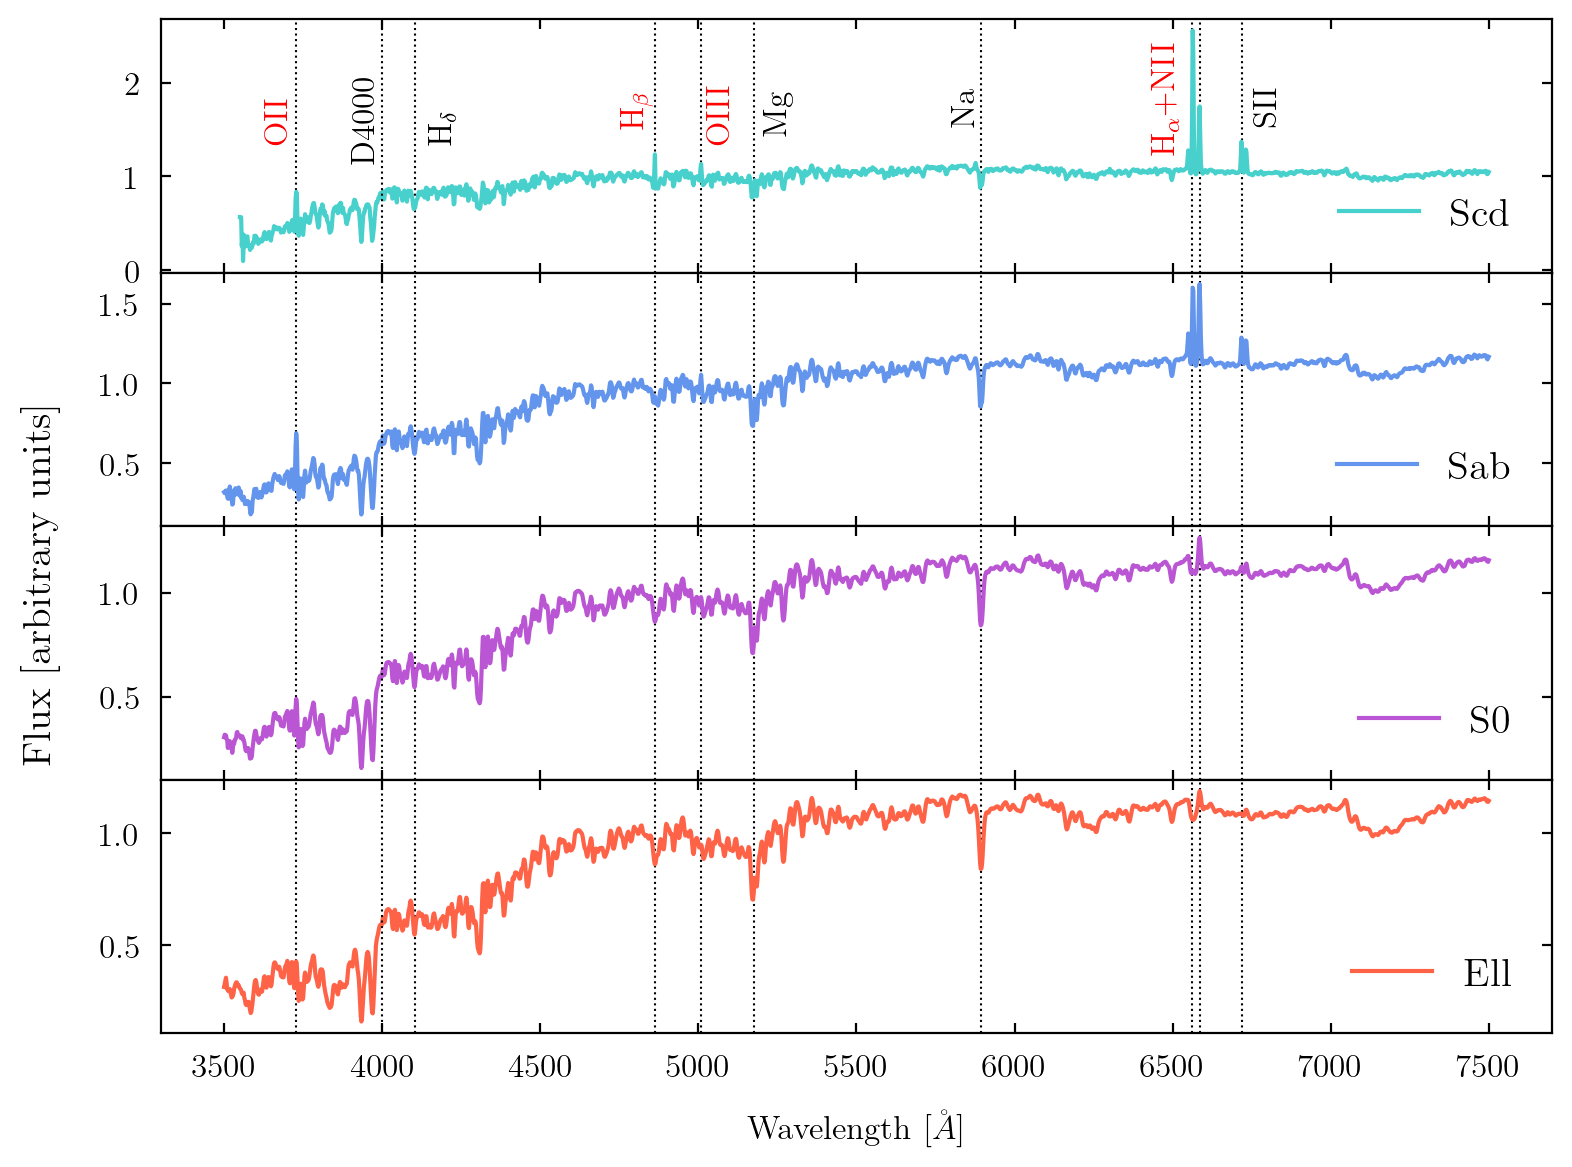

In [62]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(8, 6), gridspec_kw={'hspace': 0}, sharex=True)
colors=['tomato', 'mediumorchid', 'cornflowerblue', 'mediumturquoise']
all_spectra=[Ell_spectra, S0_spectra, Sab_spectra, Scd_spectra]
names = ['Ell', 'S0', 'Sab', 'Scd']

for i, name in enumerate(names):
    axs[3-i].plot(wave_grid, all_spectra[i], label=name, c=colors[i])
    axs[3-i].legend(loc='lower right', fontsize='large')
    
    axs[3-i].axvline(4000, lw=0.75, ls='dotted', color='black')
    # axs[3-i].axvline(4958.911, lw=1, ls='dotted', color='black')
    
    ## emission
    axs[3-i].axvline(6562.819, lw=0.75, ls='dotted', color='black', zorder=0) # halpha
    axs[3-i].axvline(4862.68, lw=0.75, ls='dotted', color='black', zorder=0) # hbeta
    axs[3-i].axvline(4102.89, lw=0.75, ls='dotted', color='black', zorder=0) # hdelta
    axs[3-i].axvline(6585.27, lw=0.75, ls='dotted', color='black', zorder=0) # NII
    axs[3-i].axvline(6718.29, lw=0.75, ls='dotted', color='black', zorder=0) # SII
    axs[3-i].axvline(3727.092, lw=0.75, ls='dotted', color='black', zorder=0) # OII
    axs[3-i].axvline(5008.240, lw=0.75, ls='dotted', color='black', zorder=0) # OIII
     
    
    ## absorption
    axs[3-i].axvline(5895.6 , lw=0.75, ls='dotted', color='black', zorder=0) # Na
    axs[3-i].axvline(5176.7 , lw=0.75, ls='dotted', color='black', zorder=0) # Mg

    # axs[3-i].axvspan(bands_D4000[0][0], bands_D4000[0][1], alpha=0.25, zorder=0, color='gray')
    # axs[3-i].axvspan(bands_D4000[1][0], bands_D4000[1][1], alpha=0.25, zorder=0, color='gray')

    # axs[3-i].axvspan(6562.819-4, 6562.819+7, alpha=0.25, zorder=0, color='gray')
    # axs[3-i].axvspan(6585.27-6, 6585.27+5, alpha=0.25, zorder=0, color='gray')

    # axs[3-i].axvspan(5008.240-5, 5008.240+5, alpha=0.25, zorder=0, color='gray')
    
    # axs[3-i].axvspan(4862.68-5, 4862.68+3.5, alpha=0.25, zorder=0, color='gray')
    
    # axs[3-i].axvspan(3727.092-5, 3727.092+7, alpha=0.25, zorder=0, color='gray')
    
    # axs[3-1].set_xlim(3650, 3750)

axs[0].annotate('OIII', (5025, 1.4), rotation=90, color='red')
axs[0].annotate(r'OII', (3625, 1.4), rotation=90, color='red')
axs[0].annotate(r'H$_\beta$', (4755, 1.6), rotation=90, color='red')
axs[0].annotate(r'H$_\alpha$+NII', (6430, 1.3), rotation=90, color='red')
axs[0].annotate(r'SII', (6755, 1.6), rotation=90)

axs[0].annotate(r'H$_\delta$', (4145, 1.4), rotation=90)

axs[0].annotate('D4000', (3900, 1.2), rotation=90)
axs[0].annotate(r'Na', (5800, 1.6), rotation=90)
axs[0].annotate(r'Mg', (5205, 1.5), rotation=90)

plt.xlabel(r'Wavelength [$\AA$]')
fig.supylabel('Flux [arbitrary units]')
plt.tight_layout()
# plt.savefig('ave_spec_UPDATED.pdf', dpi=200);

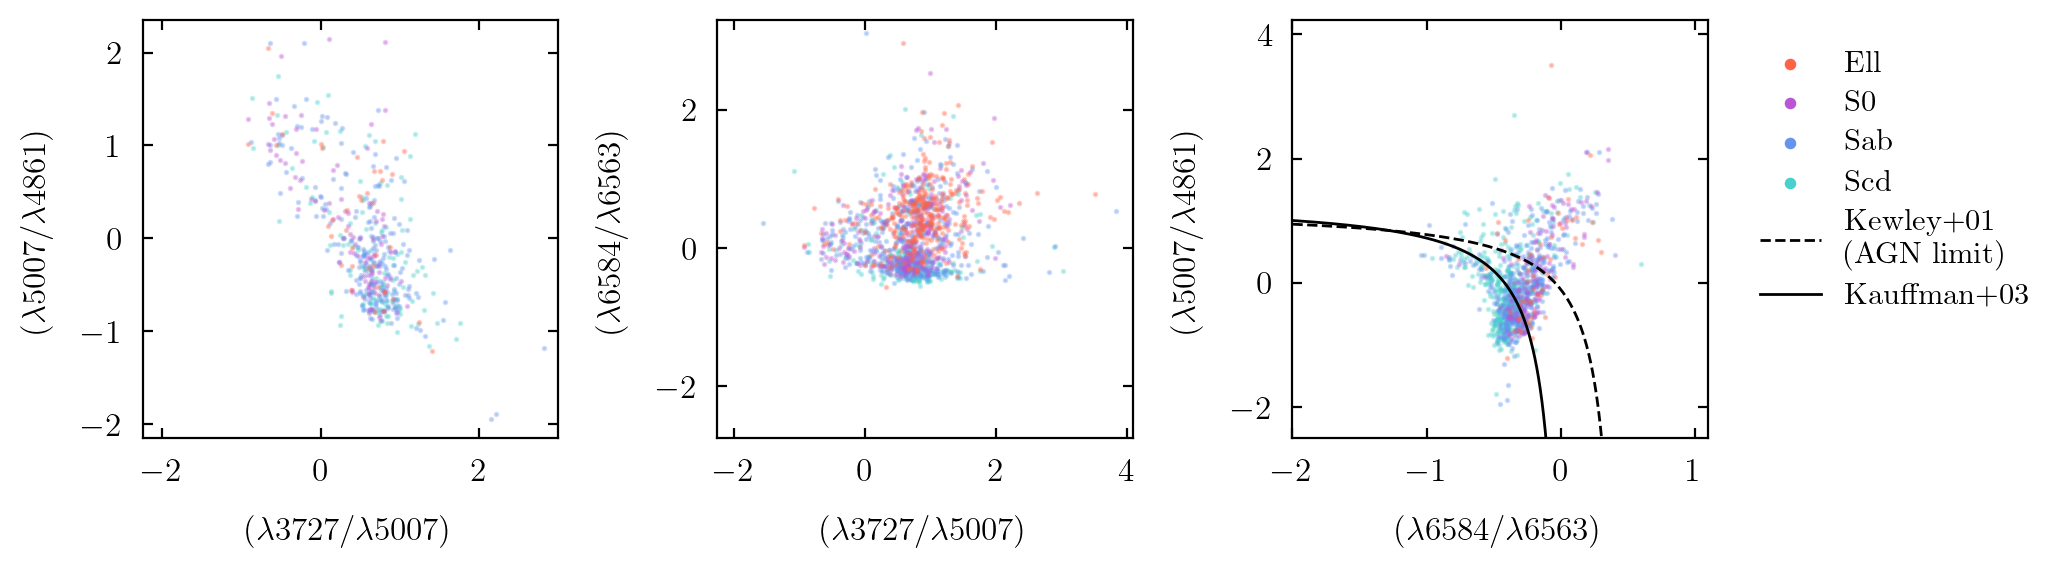

In [117]:
NII_Halphas = [NII_Halpha_ell, NII_Halpha_S0, NII_Halpha_Sab, NII_Halpha_Scd]
OIII_Hbetas = [OIII_Hbeta_ell, OIII_Hbeta_S0, OIII_Hbeta_Sab, OIII_Hbeta_Scd]
OII_OIIIs = [OII_OIII_ell, OII_OIII_S0, OII_OIII_Sab, OII_OIII_Scd]

D4000s = [D4000_ell, D4000_S0, D4000_Sab, D4000_Scd]
HdeltaAs = [HdeltaA_ell, HdeltaA_S0, HdeltaA_Sab, HdeltaA_Scd]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10.5,3))
for i, name in enumerate(names):
    ax[0].scatter(OII_OIIIs[3-i], OIII_Hbetas[3-i], c=colors[3-i], s=1, alpha=0.3) ## (λ3727/λ5007) vs (λ5007/λ4861)
    ax[1].scatter(OII_OIIIs[3-i], NII_Halphas[3-i], c=colors[3-i], s=1, alpha=0.3) ## (λ3727/λ5007) vs (λ6584/λ6563)
    ax[2].scatter(NII_Halphas[3-i], OIII_Hbetas[3-i], c=colors[3-i], s=1, alpha=0.3) ## (λ5007/λ4861) vs (λ6584/λ6563)

    ax[2].scatter([],[], c=colors[i], s=10, label=name)
    
ax[0].set_xlabel(r'($\lambda$3727/$\lambda$5007)')
ax[0].set_ylabel(r'($\lambda$5007/$\lambda$4861)')

ax[0].set_xlim(-2.25)
# ax[0].set_ylim(-1.75, 1.75)

ax[1].set_xlabel(r'($\lambda$3727/$\lambda$5007)')
ax[1].set_ylabel(r'($\lambda$6584/$\lambda$6563)')

ax[1].set_xlim(-2.25)
# ax[1].set_ylim(-2.75, 1.25)
ax[1].set_ylim(-2.75)

def kewley01(x):
    return 0.61 / (x - 0.47) + 1.19

def kauffmann03(x):
    return 0.61 / (x - 0.05) + 1.3

x_vals_1 = np.linspace(-2.0, 0.0, 2000)
x_vals_2 = np.linspace(-2.0, 0.4, 500)

ax[2].plot(x_vals_2, kewley01(x_vals_2), 'k--', lw=1, label='Kewley+01\n(AGN limit)')
ax[2].plot(x_vals_1, kauffmann03(x_vals_1), 'k-', lw=1, label='Kauffman+03')

ax[2].set_ylabel(r'($\lambda$5007/$\lambda$4861)')
ax[2].set_xlabel(r'($\lambda$6584/$\lambda$6563)')

ax[2].set_xlim(-2, 1.1)
ax[2].set_ylim(-2.5)

plt.legend(bbox_to_anchor=(1.05, 1.0))

plt.tight_layout()
plt.savefig('line_strength_ratios.pdf', dpi=200)

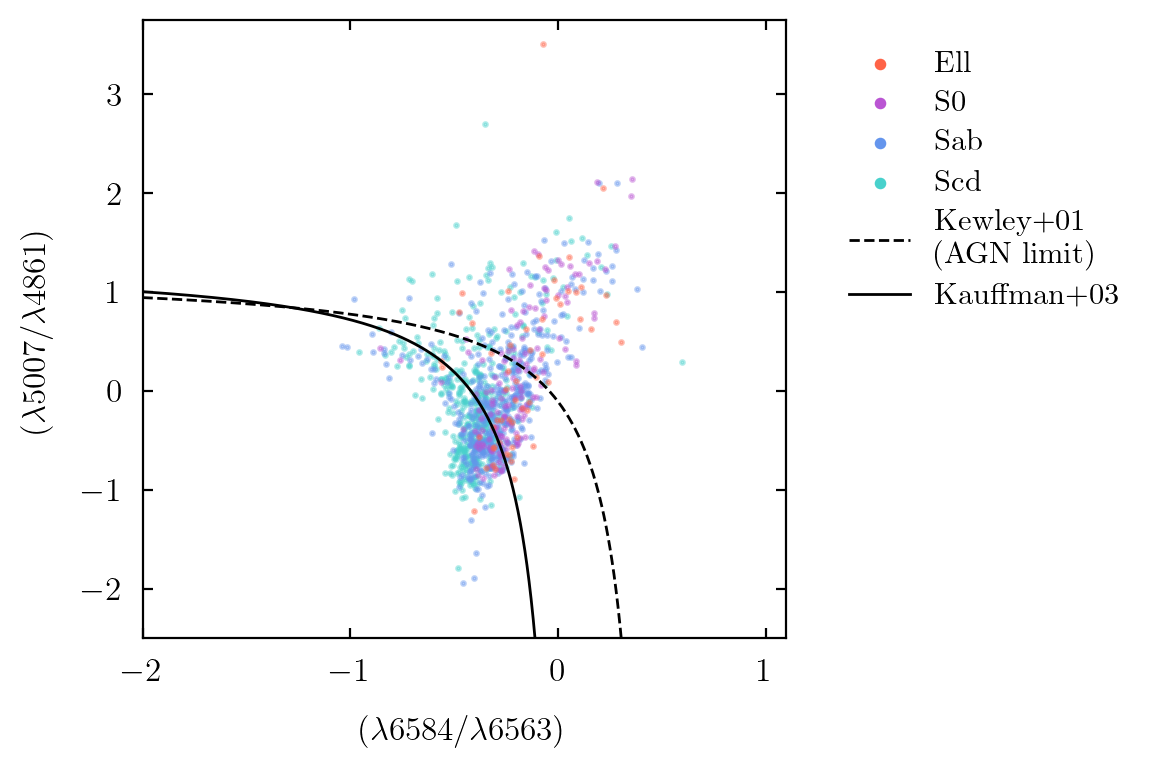

In [116]:
plt.figure(figsize=(6,4))
for i, name in enumerate(names):
    plt.scatter(NII_Halphas[3-i], OIII_Hbetas[3-i], c=colors[3-i], s=2, alpha=0.4) ## (λ5007/λ4861) vs (λ6584/λ6563)
    plt.scatter([],[], c=colors[i], s=10, label=name)

plt.plot(x_vals_2, kewley01(x_vals_2), 'k--', lw=1, label='Kewley+01\n(AGN limit)')
plt.plot(x_vals_1, kauffmann03(x_vals_1), 'k-', lw=1, label='Kauffman+03')

plt.ylabel(r'($\lambda$5007/$\lambda$4861)')
plt.xlabel(r'($\lambda$6584/$\lambda$6563)')

plt.xlim(-2, 1.1)
plt.ylim(-2.5, 3.75)

# plt.annotate('Star-Formation', (-1.6, -1))
# plt.annotate('AGN', (0.4, 1))
# plt.annotate('Composite', (0.25, -1))
plt.legend(bbox_to_anchor=(1.05, 1.0))

plt.tight_layout()
plt.savefig('for_presentation.pdf', dpi=200)

# all of my old code that I did not end up using in the final data processing/figures, abandon all hope ye who enter here

In [8]:
# initialize arrays # 
def get_flux_wave(gal_data, num_gal=200, length=3853):
    # lengths = []
    # (λ6584/λ6563) vs. (λ5007/λ4861)
    # (λ3727/λ5007) against (λ5007/λ4861)

    NII_Halpha = []
    OIII_Hbeta = []
    OII_OIII = []

    D4000s = []
    HdeltaAs = []
    
    fluxes_ave = np.zeros(length)
    count = 0
    success = False
    
    for galaxy in gal_data:
        if success is False:  
            # spectrum func needs obj_id, plate, mjd, and fiber
            obj_id, plate, mjd, fiber, z = galaxy['objID'], galaxy['plate'], galaxy['mjd'], galaxy['fiberid'], galaxy['z'] 
                # very importantly need z to correct for redshift!!!
    
            try:
                wave, flux = obs_sdss.getSdssSpectrum(obj_id, plate, mjd, fiber)
                wave = wave / (1 + z) # redshift correction
    
                # lengths.append(len(wave))
                ratio1, ratio2, ratio3 = get_bands(wave, flux)
                    
                NII_Halpha.append(ratio1)
                OIII_Hbeta.append(ratio2)
                OII_OIII.append(ratio3)

                D4000s.append(D4000_func(wave, flux))
                HdeltaAs.append(HdeltaA_func(wave, flux))
            
                if len(wave) == length:
                    # print(count)
                    
                    fluxes_ave = fluxes_ave + flux
                    wave_last = wave
    
                    count += 1
        
                if count == num_gal:
                    success = True
    
            except:
                continue

        if success is True:
            break
    # print(np.mean(lengths))            
    print('averaged', count, 'galaxies (out of', len(gal_data), 'available)')
    return wave_last, fluxes_ave/count, NII_Halpha, OIII_Hbeta, OII_OIII, D4000s, HdeltaAs

In [9]:
wave_ell, flux_ave_ell, NII_Halpha_ell, OIII_Hbeta_ell, OII_OIII_ell, D4000_ell, HdeltaA_ell = get_flux_wave(Ell_data)
wave_S0, flux_ave_S0, NII_Halpha_S0, OIII_Hbeta_S0, OII_OIII_S0, D4000_S0, HdeltaA_S0 = get_flux_wave(S0_data)
wave_Sab, flux_ave_Sab, NII_Halpha_Sab, OIII_Hbeta_Sab, OII_OIII_Sab, D4000_Sab, HdeltaA_Sab = get_flux_wave(Sab_data)
wave_Scd, flux_ave_Scd, NII_Halpha_Scd, OIII_Hbeta_Scd, OII_OIII_Scd, D4000_Scd, HdeltaA_Scd = get_flux_wave(Scd_data, length=3855)

/var/folders/32/yf45_yps5q7c22n3pzbcm9km0000gn/T/ipykernel_7309/378075089.py:20: RuntimeWarning: divide by zero encountered in log10
  return np.log10(NII/Halpha), np.log10(OIII/Hbeta), np.log10(OII/OIII)


averaged 139 galaxies (out of 2251 available)
averaged 72 galaxies (out of 1295 available)
averaged 77 galaxies (out of 1383 available)
averaged 34 galaxies (out of 872 available)


In [10]:
waves = [wave_ell, wave_S0, wave_Sab, wave_Scd]
ave_fluxes = [flux_ave_ell, flux_ave_S0, flux_ave_Sab, flux_ave_Scd]

NII_Halphas = [NII_Halpha_ell, NII_Halpha_S0, NII_Halpha_Sab, NII_Halpha_Scd]
OIII_Hbetas = [OIII_Hbeta_ell, OIII_Hbeta_S0, OIII_Hbeta_Sab, OIII_Hbeta_Scd]
OII_OIIIs = [OII_OIII_ell, OII_OIII_S0, OII_OIII_Sab, OII_OIII_Scd]

D4000s = [D4000_ell, D4000_S0, D4000_Sab, D4000_Scd]
HdeltaAs = [HdeltaA_ell, HdeltaA_S0, HdeltaA_Sab, HdeltaA_Scd]

names = ['Ell', 'S0', 'Sab', 'Scd']

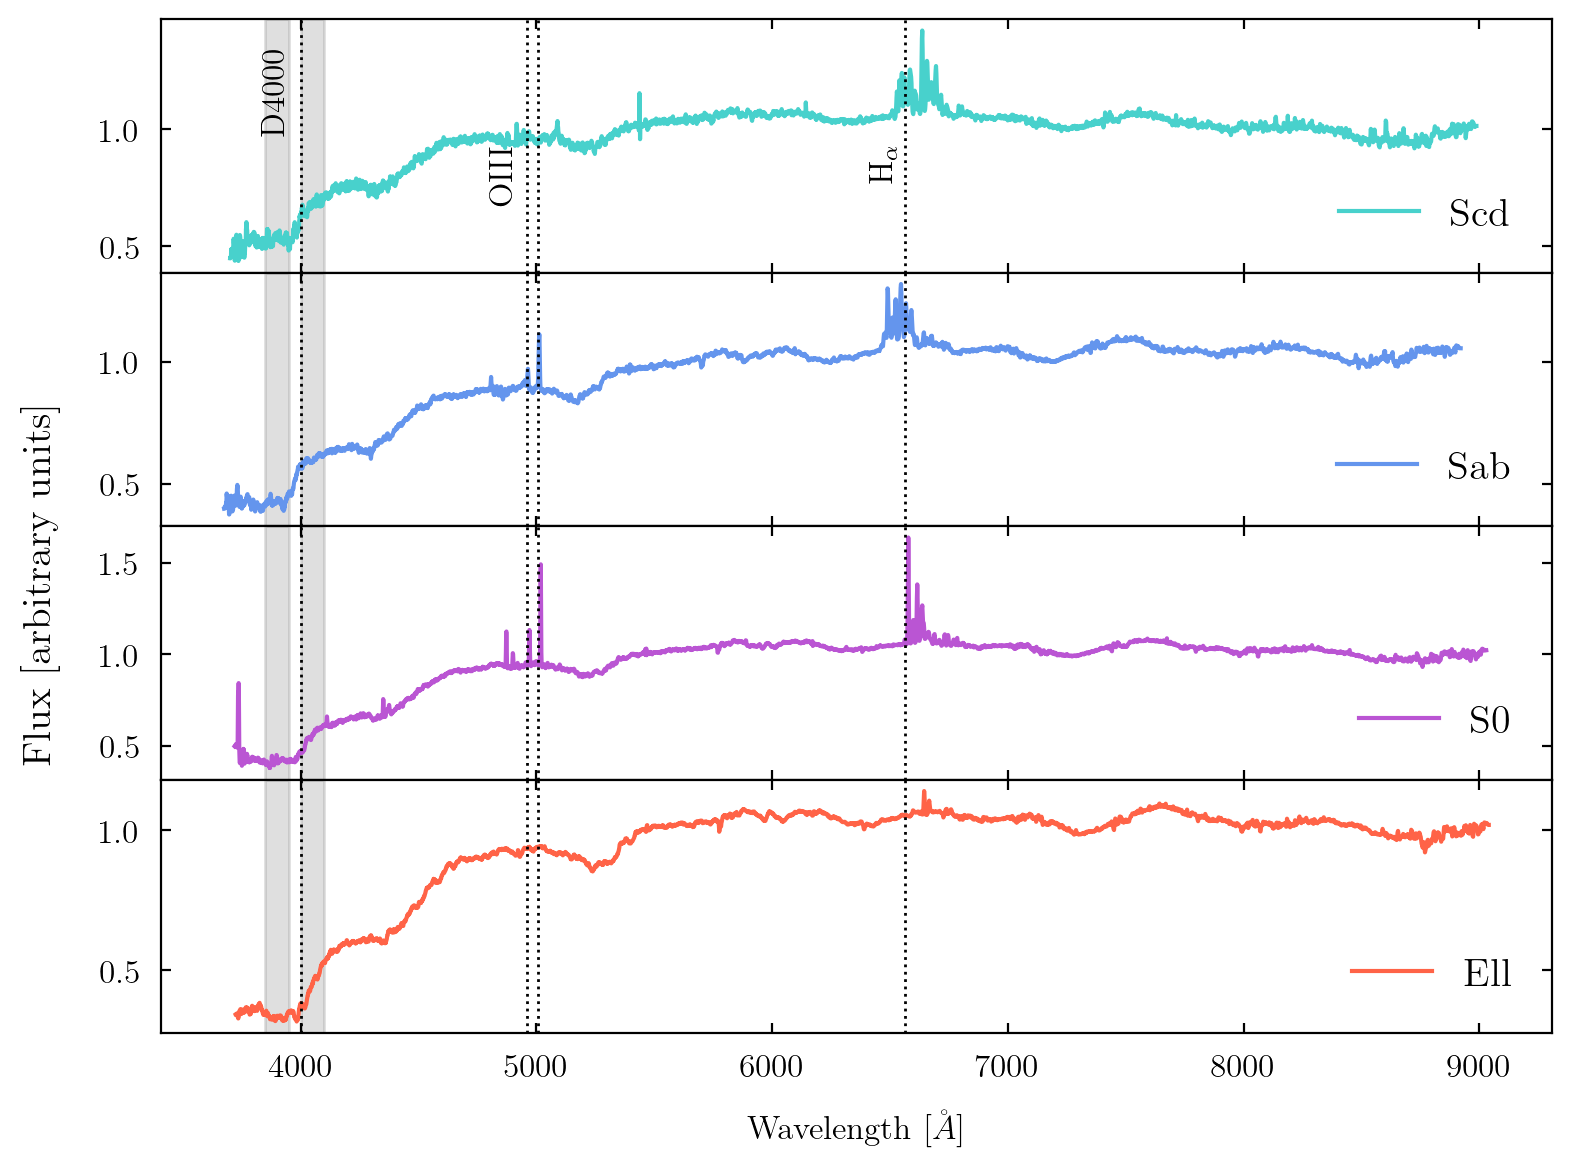

In [11]:
# (λ6584/λ6563) vs. (λ5007/λ4861)
# (λ3727/λ5007) against (λ5007/λ4861)

# λ6584 - NII
# λ6563 - Halpha
# λ5007 - OIII
# λ4861 - Hbeta
# λ3727 - OII

fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(8, 6), gridspec_kw={'hspace': 0}, sharex=True)
# fig.suptitle(r'SDSS Data vs $M_{\rm vir,curr}$ Simulations')
colors=['tomato', 'mediumorchid', 'cornflowerblue', 'mediumturquoise']

for i, name in enumerate(names):
    axs[3-i].plot(waves[i], ave_fluxes[i]/np.median(ave_fluxes[i]), label=name, c=colors[i])
    axs[3-i].legend(loc='lower right', fontsize='large')
    
    axs[3-i].axvline(4000, lw=1, ls='dotted', color='black')
    axs[3-i].axvline(4958.911, lw=1, ls='dotted', color='black')
    axs[3-i].axvline(5006.843, lw=1, ls='dotted', color='black')
    axs[3-i].axvline(6562.819 , lw=1, ls='dotted', color='black')

    # axs[3-i].axvspan(5007-25, 5007+25, alpha=0.25, zorder=0, color='gray')
    # axs[3-i].axvspan(4861-25, 4861+25, alpha=0.25, zorder=0, color='gray')

    # axs[3-i].axvspan(3727-25, 3727+25, alpha=0.25, zorder=0, color='gray')
    
    # axs[3-i].axvspan(6584-5, 6584+5, alpha=0.25, zorder=0, color='gray')
    # axs[3-i].axvspan(6563-5, 6563+5, alpha=0.25, zorder=0, color='gray')

    axs[3-i].axvspan(bands_D4000[0][0], bands_D4000[0][1], alpha=0.25, zorder=0, color='gray')
    axs[3-i].axvspan(bands_D4000[1][0], bands_D4000[1][1], alpha=0.25, zorder=0, color='gray')

axs[0].annotate('D4000', (3830, 1), rotation=90)
axs[0].annotate('OIII', (4799, 0.7), rotation=90)
axs[0].annotate(r'H$_\alpha$', (6412, 0.8), rotation=90)

plt.xlabel(r'Wavelength [$\AA$]')
fig.supylabel('Flux [arbitrary units]')
plt.tight_layout()
# plt.savefig('ave_spec.pdf', dpi=200)

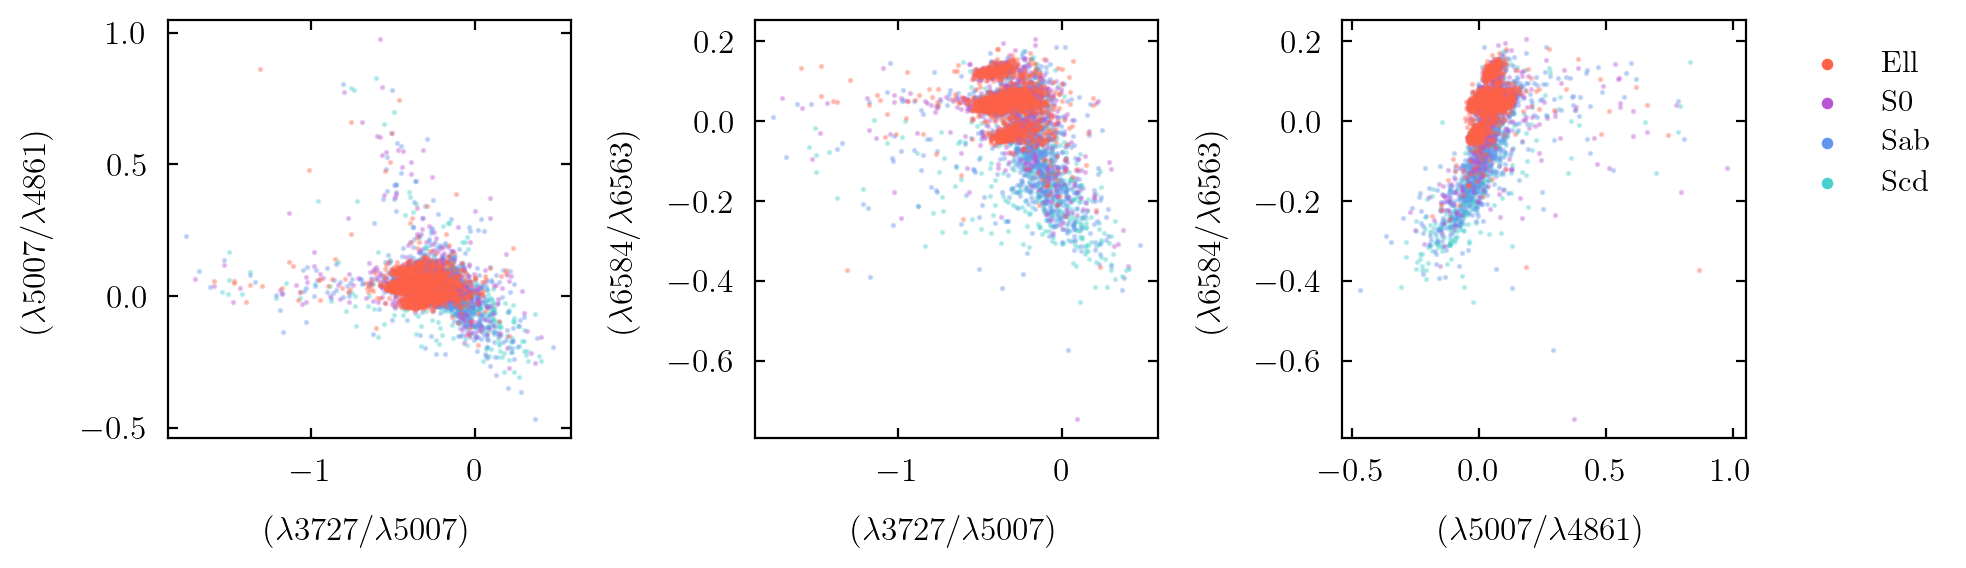

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,3))
for i, name in enumerate(names):
    ax[0].scatter(OII_OIIIs[3-i], OIII_Hbetas[3-i], c=colors[3-i], s=1, alpha=0.3) ## (λ3727/λ5007) vs (λ5007/λ4861)
    ax[1].scatter(OII_OIIIs[3-i], NII_Halphas[3-i], c=colors[3-i], s=1, alpha=0.3) ## (λ3727/λ5007) vs (λ6584/λ6563)
    ax[2].scatter(OIII_Hbetas[3-i], NII_Halphas[3-i], c=colors[3-i], s=1, alpha=0.3) ## (λ5007/λ4861) vs (λ6584/λ6563)

    ax[2].scatter([],[], c=colors[i], s=10, label=name)
    
ax[0].set_xlabel(r'($\lambda$3727/$\lambda$5007)')
ax[0].set_ylabel(r'($\lambda$5007/$\lambda$4861)')

ax[1].set_xlabel(r'($\lambda$3727/$\lambda$5007)')
ax[1].set_ylabel(r'($\lambda$6584/$\lambda$6563)')

ax[2].set_xlabel(r'($\lambda$5007/$\lambda$4861)')
ax[2].set_ylabel(r'($\lambda$6584/$\lambda$6563)')

plt.legend(bbox_to_anchor=(1.05, 1.0))

plt.tight_layout()
# plt.savefig('line_strength_ratios.pdf', dpi=200)

Ell D4000 average: 1.7809857 HdeltaA average: -1.4329252678481033
number of galaxies: 2247 

S0 D4000 average: 1.700578 HdeltaA average: -0.7722323998192142
number of galaxies: 1295 

Sab D4000 average: 1.5317545 HdeltaA average: 0.3960131904850848
number of galaxies: 1383 

Scd D4000 average: 1.3576878 HdeltaA average: 1.8850605090493053
number of galaxies: 872 



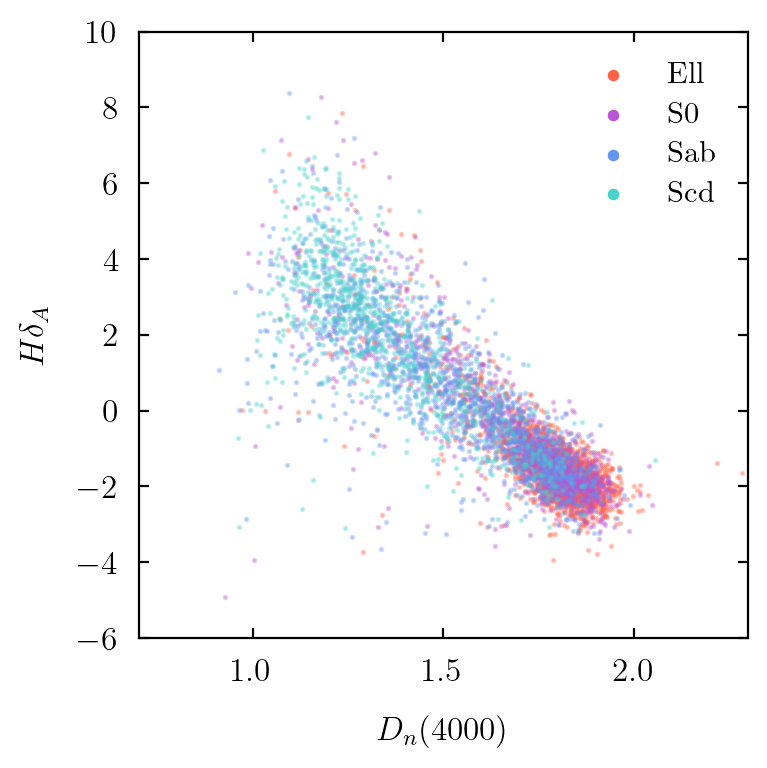

In [20]:
plt.figure(figsize=(4,4))
for i, name in enumerate(names):
    plt.scatter(D4000s[i], HdeltaAs[i], c=colors[i], s=1, alpha=0.3)
    plt.scatter([],[],c=colors[i], s=10, label=name)
    print(name, "D4000 average:", np.mean(D4000s[i]), "HdeltaA average:", np.mean(HdeltaAs[i]))
    print("number of galaxies:", len(D4000s[i]), "\n")

plt.xlabel(r"$D_n(4000)$")
plt.ylabel(r"$H\delta_A$")

plt.xlim(0.7, 2.3)
plt.ylim(-6, 10)

plt.legend();
plt.tight_layout();
plt.savefig('hdeltaa_vs_d4000.pdf', dpi=200);

In [ ]:
# D4000_ell_arr = np.array(D4000_ell)
# HdeltaA_ell_arr = np.array(HdeltaA_ell)

# strange_ell_mask = (D4000_ell_arr < 1.5) & (HdeltaA_ell_arr > 2)
# strange_ell_index = np.where(strange_ell_mask)[0][0]

# print(strange_ell_index)

# print("D4000:", D4000_ell[strange_ell_index], "HdA:", HdeltaA_ell[strange_ell_index])
# obs_sdss.imageAndSpectrum(Ell_data[strange_ell_index])

In [ ]:
# initialize arrays # 
def ALT_get_flux_wave(gal_data, num_gal=60, length=3853):
    # lengths = []
    
    fluxes_ave = []
    count = 0
    success = False

    for galaxy in gal_data:
        if success is False:  
            # spectrum func needs obj_id, plate, mjd, and fiber
            obj_id, plate, mjd, fiber, z = galaxy['objID'], galaxy['plate'], galaxy['mjd'], galaxy['fiberid'], galaxy['z'] 
                # very importantly need z to correct for redshift!!!
    
            try:
                wave, flux = obs_sdss.getSdssSpectrum(obj_id, plate, mjd, fiber)
                wave = wave / (1 + z) # redshift correction

                # lengths.append(len(wave))
            
                if len(wave) == length:
                    count += 1
                    # print(count)
                    
                    fluxes_ave.append(flux)
                    wave_last = wave
        
                if count == num_gal:
                    success = True
    
            except:
                continue

        if success is True:
            break
    # print(np.mean(lengths))
    
    print('averaged', count, 'galaxies (out of', len(gal_data), 'available)')
    return wave_last, np.median(np.array(fluxes_ave), axis=0)

In [ ]:
wave_ell, flux_ave_ell = ALT_get_flux_wave(Ell_data)
wave_S0, flux_ave_S0 = ALT_get_flux_wave(S0_data)
wave_Sab, flux_ave_Sab = ALT_get_flux_wave(Sab_data)
wave_Scd, flux_ave_Scd = ALT_get_flux_wave(Scd_data, length=3855)

In [ ]:
waves = [wave_ell, wave_S0, wave_Sab, wave_Scd]
ave_fluxes = [flux_ave_ell, flux_ave_S0, flux_ave_Sab, flux_ave_Scd]
names = ['Ell', 'S0', 'Sab', 'Scd']

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), gridspec_kw={'hspace': 0}, sharex=True)
# fig.suptitle(r'SDSS Data vs $M_{\rm vir,curr}$ Simulations')
# colors=['firebrick', 'medium_blue', '', '']

for i, name in enumerate(names):
    axs[3-i].plot(waves[i], ave_fluxes[i]/np.mean(ave_fluxes[i]), label=name) #, c=colors[i])
    axs[3-i].legend(loc='lower right')
    axs[3-i].axvline(4000, lw=1, ls='dotted', color='black')
    # axs[3-i].axvline(4317.139, lw=1, ls='dotted', color='black')
    axs[3-i].axvline(4958.911, lw=1, ls='dotted', color='black')
    axs[3-i].axvline(6562.819 , lw=1, ls='dotted', color='black')
    # axs[3-i].axvline(4000)

axs[0].annotate('D4000', (3900, 1.2), rotation=90)
axs[0].annotate('OIII', (4859, 1.25), rotation=90)
axs[0].annotate(r'H$_\alpha$', (6462, 0.9), rotation=90)

plt.xlabel(r'Wavelength [$\AA$]')
fig.supylabel('Flux [arbitrary units]')
plt.tight_layout()
plt.show()